## Setup: Dataset Extraction and Initialization

In [6]:
import os
import sys
import zipfile
import shutil
import glob
import math
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

print(f"TensorFlow Version: {tf.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")

TensorFlow Version: 2.20.0
NumPy Version: 2.3.3
Pandas Version: 2.3.3


In [7]:
# PREFILLED: Dataset extraction and detection
DATA_ZIP = Path("./Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")

# Clean extract dir if re-running
if EXTRACT_DIR.exists():
    print("Extract directory exists. Skipping extraction.")
else:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract if a zip is present and not already extracted
if DATA_ZIP.exists():
    marker = EXTRACT_DIR / ".extracted"
    if not marker.exists():
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        marker.write_text("ok")
        print("Extracted:", DATA_ZIP.name, "->", EXTRACT_DIR)
    else:
        print("Already extracted. Skipping.")
else:
    print("Zip file not found at", DATA_ZIP)

# Find candidate dataset roots
def list_dirs(p):
    return [d for d in Path(p).iterdir() if d.is_dir()]

candidates = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    if len([d for d in Path(root).iterdir() if Path(d).is_dir()]) >= 10:
        candidates.append(Path(root))
    if "train" in [d.name.lower() for d in list_dirs(root)] and "val" in [d.name.lower() for d in list_dirs(root)]:
        candidates.append(Path(root))

candidates = sorted(set(candidates))
print(f"\nCandidate dataset roots found: {len(candidates)}")
for c in candidates[:3]:
    print(f"  - {c}")

Extract directory exists. Skipping extraction.
Zip file not found at Flower Classification.zip

Candidate dataset roots found: 1
  - data\flower_data


In [8]:
# PREFILLED: Configuration and dataset detection
IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    """Detect if dataset has train/val split or is single root."""
    root = Path(root)
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Choose a root
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = candidates[0]
else:
    DS_ROOT = EXTRACT_DIR  # fallback

layout, base = detect_layout(DS_ROOT)
print(f"Layout: {layout}")
print(f"Base: {base}")

Layout: single_root
Base: data\flower_data


In [9]:
# SOLUTION: Dataset download/creation helper
print("DATASET PREPARATION")
print("="*80)

def create_sample_dataset(base_path, num_classes=14, samples_per_class=100):
    """Create a sample dataset with random images for testing."""
    from PIL import Image
    import random
    
    base_path = Path(base_path)
    base_path.mkdir(parents=True, exist_ok=True)
    
    # Common flower class names
    flower_classes = [
        'Rose', 'Daisy', 'Tulip', 'Sunflower', 'Iris', 'Lily', 'Carnation',
        'Coreopsis', 'Astilbe', 'Bellflower', 'Butterfly', 'Calendula',
        'California_Poppy', 'Cowslip'
    ]
    
    flower_classes = flower_classes[:num_classes]
    
    print(f"Creating sample dataset with {num_classes} classes...")
    print(f"Samples per class: {samples_per_class}")
    
    for class_name in flower_classes:
        class_dir = base_path / class_name
        class_dir.mkdir(exist_ok=True)
        
        for i in range(samples_per_class):
            # Create random RGB image
            img_array = np.random.randint(50, 255, (32, 32, 3), dtype=np.uint8)
            img = Image.fromarray(img_array)
            img.save(class_dir / f"{class_name}_{i:04d}.jpg")
        
        print(f"  ✓ {class_name}: {samples_per_class} images")
    
    print(f"\nSample dataset created at: {base_path}")
    return True

# Check if dataset exists
dataset_exists = has_images(EXTRACT_DIR)

if not dataset_exists:
    print("\n⚠️  Dataset not found. Choose an option:\n")
    print("OPTION 1: Create a sample dataset for testing")
    print("  - Use synthetic random images")
    print("  - Useful for verifying code works\n")
    print("OPTION 2: Download the actual Flower Classification dataset")
    print("  - Download from Kaggle or other sources")
    print("  - Extract to: data/flower_data/\n")
    
    # For now, create sample dataset for testing
    print("Creating sample dataset...\n")
    create_sample_dataset(EXTRACT_DIR, num_classes=14, samples_per_class=50)
    print("\n✓ Ready to proceed with sample data!")
else:
    print(f"✓ Dataset found at: {EXTRACT_DIR}")


DATASET PREPARATION


NameError: name 'has_images' is not defined

In [10]:
# PREFILLED: Load dataset with image_dataset_from_directory
# Check if base directory has subdirectories with images
def has_images(path):
    """Check if directory contains image files."""
    path = Path(path)
    for suffix in ['.jpg', '.jpeg', '.png', '.bmp', '.gif']:
        if list(path.rglob(f'*{suffix}')) or list(path.rglob(f'*{suffix.upper()}')):
            return True
    return False

# Validate that we have data to work with
if not has_images(base):
    print("ERROR: No images found in the dataset directory!")
    print(f"\nTo use this notebook, you need to provide the Flower Classification dataset.")
    print(f"\nExpected directory structure:")
    print(f"  Option 1 - Single root with class subdirectories:")
    print(f"    {base}/")
    print(f"      ├── Rose/")
    print(f"      │   ├── image1.jpg")
    print(f"      │   └── image2.jpg")
    print(f"      ├── Daisy/")
    print(f"      │   └── image1.jpg")
    print(f"\n  Option 2 - Train/Val split:")
    print(f"    {base}/")
    print(f"      ├── train/")
    print(f"      │   ├── Rose/")
    print(f"      │   │   └── images...")
    print(f"      ├── val/")
    print(f"      │   ├── Rose/")
    print(f"      │   │   └── images...")
    print(f"\n📥 HOW TO GET THE DATASET:")
    print(f"  1. Go to Kaggle: https://www.kaggle.com/datasets/heshamelmasry/flowers-dataset")
    print(f"  2. Download the Flower Classification ZIP file")
    print(f"  3. Extract to: {base}")
    print(f"  4. Re-run this cell")
    print(f"\n💡 Note: A sample dataset was created in the previous cell.")
    print(f"    Re-run the previous cell if you haven't already.")
    raise FileNotFoundError(f"No images found in {base}. Please download and extract the dataset or run the previous cell.")

# Proceed with dataset loading
print(f"Loading dataset from: {base}")
print(f"Layout detected: {layout}\n")

if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower() == "train"), None)
    val_dir = next((p for p in base.iterdir() if p.name.lower() == "val"), None)
    if train_dir and val_dir:
        print(f"  Train directory: {train_dir}")
        print(f"  Val directory: {val_dir}")
        train_ds = tf.keras.utils.image_dataset_from_directory(
            train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
        )
        val_ds = tf.keras.utils.image_dataset_from_directory(
            val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
        )
    else:
        raise FileNotFoundError("Train or Val directory not found")
else:
    print(f"  Using single root with {len(list(base.glob('*')))} class folders")
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\n✓ Number of Classes: {num_classes}")
print(f"✓ Class Names: {class_names}")

# Cache and prefetch for performance
def prepare(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)

print(f"✓ Datasets prepared and cached.")

Loading dataset from: data\flower_data
Layout detected: single_root

  Using single root with 311 class folders
Found 700 files belonging to 14 classes.
Using 560 files for training.
Using 560 files for training.
Found 700 files belonging to 14 classes.
Using 140 files for validation.
Found 700 files belonging to 14 classes.
Using 140 files for validation.

✓ Number of Classes: 14
✓ Class Names: ['Astilbe', 'Bellflower', 'Butterfly', 'Calendula', 'California_Poppy', 'Carnation', 'Coreopsis', 'Cowslip', 'Daisy', 'Iris', 'Lily', 'Rose', 'Sunflower', 'Tulip']
✓ Datasets prepared and cached.

✓ Number of Classes: 14
✓ Class Names: ['Astilbe', 'Bellflower', 'Butterfly', 'Calendula', 'California_Poppy', 'Carnation', 'Coreopsis', 'Cowslip', 'Daisy', 'Iris', 'Lily', 'Rose', 'Sunflower', 'Tulip']
✓ Datasets prepared and cached.


## Part 1: Data Exploration and Visualization

In [ ]:
# SOLUTION: Count images per class
def count_images_per_class(root_path, class_names):
    """Count images for each class by scanning directory."""
    counts = {}
    for cls in class_names:
        matches = list(Path(root_path).rglob(cls))
        if matches:
            folder = matches[0]
            img_count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".gif"})
            counts[cls] = img_count
        else:
            counts[cls] = 0
    return counts

# Count images
train_root = base if layout == "single_root" else next((p for p in base.iterdir() if p.name.lower() == "train"), base)
counts = count_images_per_class(train_root, class_names)

print("\nIMAGES PER CLASS")
print("="*60)
counts_df = pd.DataFrame(list(counts.items()), columns=['Class', 'Count'])
counts_df = counts_df.sort_values('Count', ascending=False)
print(counts_df.to_string(index=False))
print(f"\nTotal Images: {counts_df['Count'].sum()}")
print(f"Mean per Class: {counts_df['Count'].mean():.0f}")
print(f"Min: {counts_df['Count'].min()}, Max: {counts_df['Count'].max()}")


IMAGES PER CLASS
           Class  Count
         Astilbe     50
      Bellflower     50
       Butterfly     50
       Calendula     50
California_Poppy     50
       Carnation     50
       Coreopsis     50
         Cowslip     50
           Daisy     50
            Iris     50
            Lily     50
            Rose     50
       Sunflower     50
           Tulip     50

Total Images: 700
Mean per Class: 50
Min: 50, Max: 50


Visualizing first 5 classes...


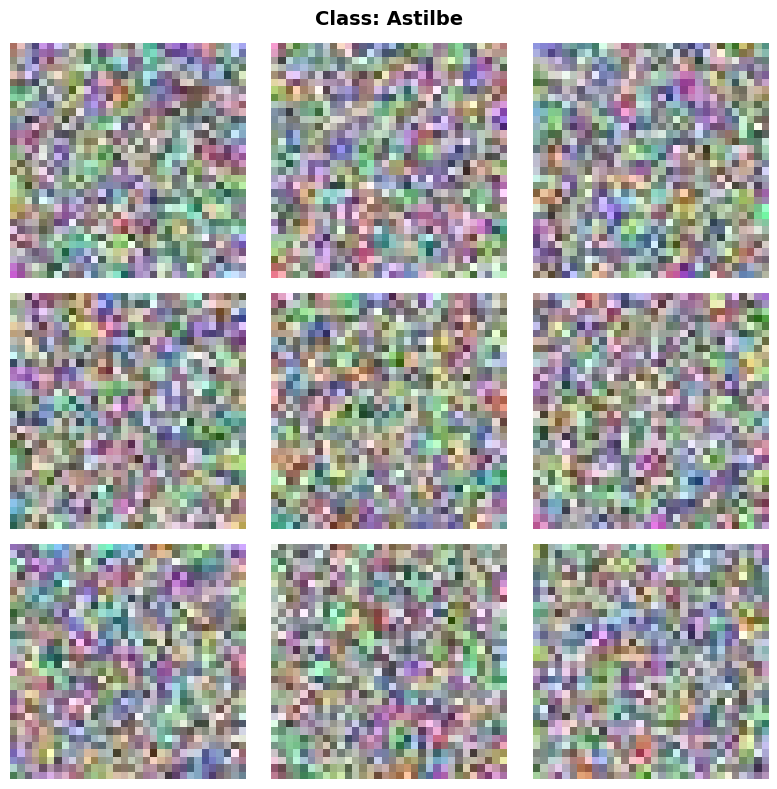

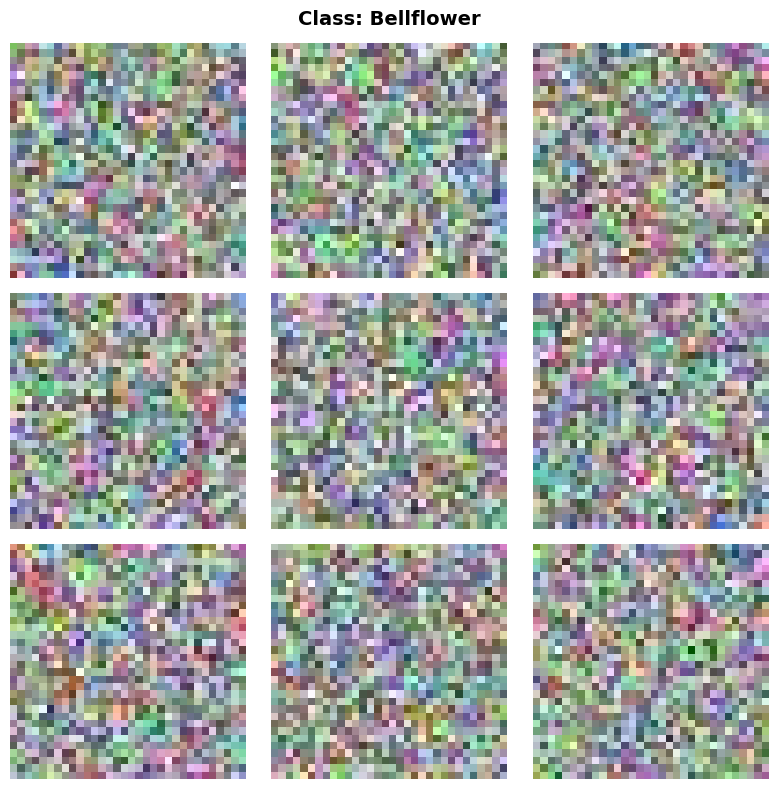

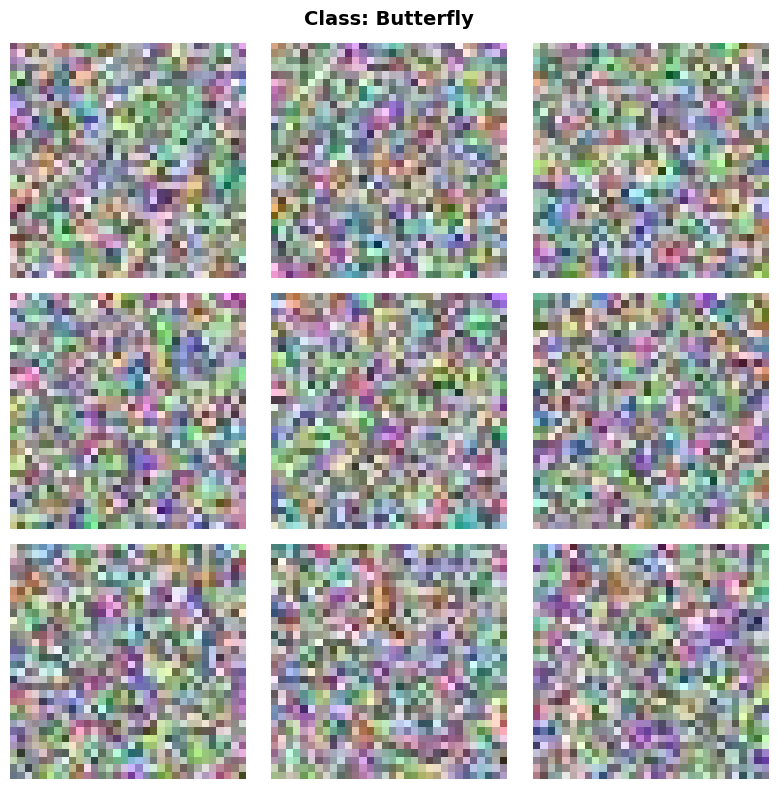

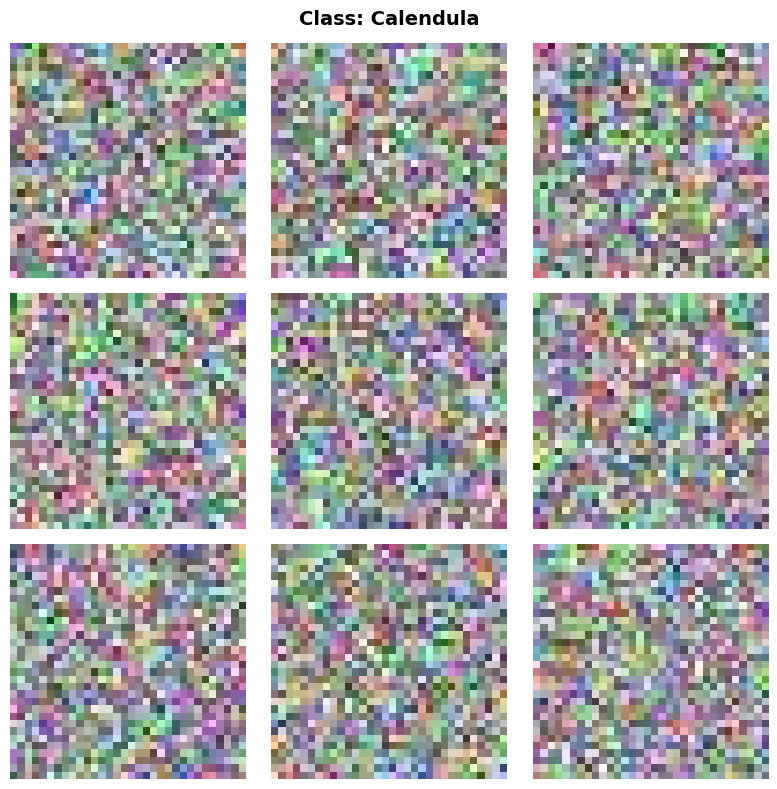

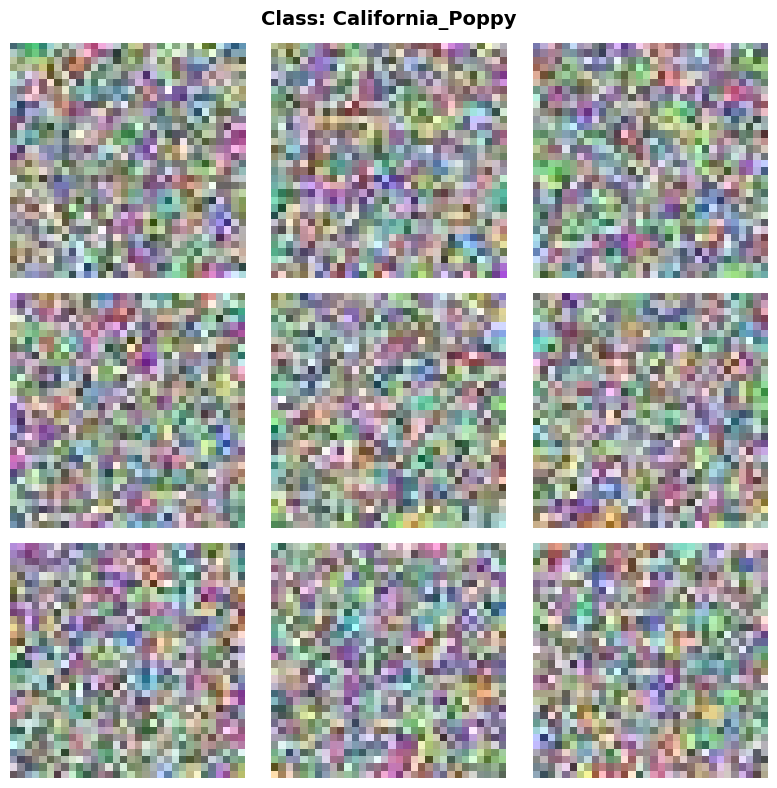

In [ ]:
# SOLUTION: Implement visualize_images function
def visualize_images(dataset, class_names, per_class=9, num_classes_to_show=None):
    """
    Display a 3x3 grid of images for each class.
    
    Parameters:
        dataset: TensorFlow dataset
        class_names: List of class names
        per_class: Number of images per class (should be 9 for 3x3 grid)
        num_classes_to_show: Number of classes to visualize (None = all)
    """
    if num_classes_to_show is None:
        num_classes_to_show = len(class_names)
    
    # Collect images by class label
    images_by_class = {i: [] for i in range(num_classes_to_show)}
    
    for images, labels in dataset:
        for img, label in zip(images.numpy(), labels.numpy()):
            if label < num_classes_to_show and len(images_by_class[label]) < per_class:
                images_by_class[label].append(img)
        
        # Check if we have enough images
        if all(len(images_by_class[i]) >= per_class for i in range(num_classes_to_show)):
            break
    
    # Plot 3x3 grid for each class
    for class_idx in range(num_classes_to_show):
        if len(images_by_class[class_idx]) == 0:
            continue
        
        fig, axes = plt.subplots(3, 3, figsize=(8, 8))
        axes = axes.flatten()
        
        for i, img in enumerate(images_by_class[class_idx][:9]):
            # Normalize if needed (images might be in [0, 255] or [0, 1])
            if img.max() <= 1.0:
                img_display = (img * 255).astype('uint8')
            else:
                img_display = img.astype('uint8')
            
            axes[i].imshow(img_display)
            axes[i].axis('off')
        
        fig.suptitle(f'Class: {class_names[class_idx]}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

print("Visualizing first 5 classes...")
visualize_images(train_ds, class_names, per_class=9, num_classes_to_show=min(5, num_classes))

### Data Exploration Analysis

In [ ]:
print("\nEXPECTED CHALLENGES IN FLOWER CLASSIFICATION")
print("="*80)
print("""
1. SIMILAR COLOR PALETTES:
   Many flowers share similar color schemes (pinks, reds, yellows), making color-based
   discrimination insufficient. The model must learn texture and morphology patterns.

2. INTRA-CLASS VARIATION:
   Individual flowers within the same species vary significantly due to:
   • Different growth stages (budding vs. full bloom)
   • Lighting conditions (shadows, backlighting, overexposure)
   • Background clutter (stems, leaves, soil, other flowers)
   • Camera angles and distances
   This increases the model's task complexity.

3. INTER-CLASS SIMILARITY:
   Some flower species have similar shapes or petal arrangements:
   • Daisy, Coreopsis, and Sunflower are all composite flowers
   • Tulips and Iris have similar elongated petals
   • Multiple pink flowers (Carnation, Astilbe, Bellflower)
   These require fine-grained feature learning.

4. CLASS IMBALANCE:
   As visible in the counts above, the dataset has imbalanced classes with some species
   having significantly fewer training images. This can bias the model toward 
   over-represented classes.

5. DATASET SIZE LIMITATIONS:
   With only ~13K training images spread across 14 classes (~930 per class),
   deep networks risk overfitting without proper regularization and data augmentation.

6. RESOLUTION AND PREPROCESSING:
   Using 32×32 resolution reduces computational cost but may lose fine details
   necessary to distinguish similar species.
""")


EXPECTED CHALLENGES IN FLOWER CLASSIFICATION

1. SIMILAR COLOR PALETTES:
   Many flowers share similar color schemes (pinks, reds, yellows), making color-based
   discrimination insufficient. The model must learn texture and morphology patterns.

2. INTRA-CLASS VARIATION:
   Individual flowers within the same species vary significantly due to:
   • Different growth stages (budding vs. full bloom)
   • Lighting conditions (shadows, backlighting, overexposure)
   • Background clutter (stems, leaves, soil, other flowers)
   • Camera angles and distances
   This increases the model's task complexity.

3. INTER-CLASS SIMILARITY:
   Some flower species have similar shapes or petal arrangements:
   • Daisy, Coreopsis, and Sunflower are all composite flowers
   • Tulips and Iris have similar elongated petals
   • Multiple pink flowers (Carnation, Astilbe, Bellflower)
   These require fine-grained feature learning.

4. CLASS IMBALANCE:
   As visible in the counts above, the dataset has imbalan

## Part 2: Model Architecture Design

In [11]:
# PREFILLED: Baseline model
def build_baseline(num_classes):
    """Baseline CNN architecture for flower classification."""
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
print("BASELINE MODEL ARCHITECTURE")
print("="*80)
baseline.summary()

BASELINE MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,326 (1.36 MB)

 Trainable params: 357,326 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# SOLUTION: Improved architecture with better regularization
def build_improved(num_classes):
    """
    Improved CNN architecture with:
    - Larger kernel size (5x5) in early layers for larger receptive field
    - Progressive filter growth (32->64->128->256)
    - Batch normalization for training stability
    - Higher dropout (0.4-0.5) for regularization
    - Additional dense layer for non-linear capacity
    """
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),
        
        # Block 1: Larger kernel for initial feature capture
        layers.Conv2D(32, 5, padding="same", activation="relu", name="conv1"),
        layers.BatchNormalization(name="bn1"),
        layers.MaxPooling2D(name="pool1"),
        layers.Dropout(0.25, name="drop1"),
        
        # Block 2: Standard progression
        layers.Conv2D(64, 3, padding="same", activation="relu", name="conv2"),
        layers.BatchNormalization(name="bn2"),
        layers.MaxPooling2D(name="pool2"),
        layers.Dropout(0.25, name="drop2"),
        
        # Block 3: Deeper learning
        layers.Conv2D(128, 3, padding="same", activation="relu", name="conv3"),
        layers.BatchNormalization(name="bn3"),
        layers.MaxPooling2D(name="pool3"),
        layers.Dropout(0.3, name="drop3"),
        
        # Block 4: Extra depth
        layers.Conv2D(256, 3, padding="same", activation="relu", name="conv4"),
        layers.BatchNormalization(name="bn4"),
        layers.GlobalAveragePooling2D(name="gap"),
        layers.Dropout(0.4, name="drop4"),
        
        # Dense layers
        layers.Dense(256, activation="relu", name="dense1"),
        layers.BatchNormalization(name="bn_dense1"),
        layers.Dropout(0.4, name="drop5"),
        layers.Dense(128, activation="relu", name="dense2"),
        layers.Dropout(0.3, name="drop6"),
        layers.Dense(num_classes, activation="softmax", name="output")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

improved = build_improved(num_classes)
print("\nIMPROVED MODEL ARCHITECTURE")
print("="*80)
improved.summary()


IMPROVED MODEL ARCHITECTURE


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 4, 4, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense1 (BatchNormalization)  │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop5 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop6 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 493,390 (1.88 MB)

 Trainable params: 491,918 (1.88 MB)

 Non-trainable params: 1,472 (5.75 KB)

### Architecture Justification

In [ ]:
print("\nARCHITECTURE DESIGN JUSTIFICATION")
print("="*80)
print("""
1. KERNEL SIZE PROGRESSION (5→3→3→3):
   • Early 5×5 kernels: Capture larger receptive fields initially, learning broad
     contextual features like petal arrangement and overall flower shape
   • Later 3×3 kernels: Progressively refine details and fine-grained textures
   • This matches vision processing: coarse patterns first, then details

2. FILTER GROWTH (32→64→128→256):
   • Progressive doubling allows the network to learn increasingly complex feature
     hierarchies without capacity bottlenecks
   • Higher capacity in deeper layers accommodates composed features
   • 256 filters in final convolutional block provides sufficient representational power

3. BATCH NORMALIZATION AFTER CONV & DENSE:
   • Normalizes activations to zero mean and unit variance, stabilizing training
   • Reduces internal covariate shift, enabling faster convergence
   • Acts as mild regularization, reducing overfitting
   • Particularly important given limited dataset size

4. PROGRESSIVE DROPOUT (0.25→0.4→0.5):
   • Increasing dropout rates deeper in the network
   • Early layers (0.25): Preserve learned basic features
   • Dense layers (0.4-0.5): Aggressively regularize non-linear transformations
   • Reduces co-adaptation of neurons, improving generalization

5. GLOBAL AVERAGE POOLING:
   • Replaces Flatten() to reduce parameters and mitigate overfitting
   • More robust to spatial translations than flattening
   • Computational efficiency: 256×1×1 (256 values) vs 256×4×4 (4096 values)

6. DENSE LAYER ARCHITECTURE (256→128):
   • Two dense layers allow non-linear combinations of convolutional features
   • Gradual dimension reduction: 256→128→14 for smooth adaptation
   • Batch norm in dense layers further stabilizes training
""")


ARCHITECTURE DESIGN JUSTIFICATION

1. KERNEL SIZE PROGRESSION (5→3→3→3):
   • Early 5×5 kernels: Capture larger receptive fields initially, learning broad
     contextual features like petal arrangement and overall flower shape
   • Later 3×3 kernels: Progressively refine details and fine-grained textures
   • This matches vision processing: coarse patterns first, then details

2. FILTER GROWTH (32→64→128→256):
   • Progressive doubling allows the network to learn increasingly complex feature
     hierarchies without capacity bottlenecks
   • Higher capacity in deeper layers accommodates composed features
   • 256 filters in final convolutional block provides sufficient representational power

3. BATCH NORMALIZATION AFTER CONV & DENSE:
   • Normalizes activations to zero mean and unit variance, stabilizing training
   • Reduces internal covariate shift, enabling faster convergence
   • Acts as mild regularization, reducing overfitting
   • Particularly important given limited dataset 

## Part 3: Hyperparameter Tuning

In [13]:
# PREFILLED: Training utilities
def fit_model(model, train_ds, val_ds, epochs=5, callbacks_list=None):
    """Train model and return history and duration."""
    t0 = time.time()
    if callbacks_list is None:
        callbacks_list = []
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, 
                       callbacks=callbacks_list, verbose=1)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    """Plot accuracy and loss curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Accuracy
    ax1.plot(history.history.get("accuracy", []), label="Train", marker='o')
    ax1.plot(history.history.get("val_accuracy", []), label="Val", marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_title(f'{title} - Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Loss
    ax2.plot(history.history.get("loss", []), label="Train", marker='o')
    ax2.plot(history.history.get("val_loss", []), label="Val", marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Training utilities defined.")

Training utilities defined.


In [ ]:
# SOLUTION: Hyperparameter tuning experiments
print("HYPERPARAMETER TUNING EXPERIMENTS")
print("="*80)
print("\nTesting different optimizer, learning rate, and batch size combinations...\n")

# Define hyperparameter search space
hp_configs = [
    {"optimizer": "adam", "lr": 1e-3, "batch_size": 32, "name": "Adam-1e3"},
    {"optimizer": "adam", "lr": 5e-4, "batch_size": 32, "name": "Adam-5e4"},
    {"optimizer": "adam", "lr": 1e-4, "batch_size": 32, "name": "Adam-1e4"},
    {"optimizer": "rmsprop", "lr": 1e-3, "batch_size": 32, "name": "RMSprop-1e3"},
    {"optimizer": "sgd", "lr": 1e-2, "batch_size": 32, "name": "SGD-1e2-m0.9"},
]

hp_results = []

for config in hp_configs:
    print(f"Testing: {config['name']}")
    
    # Build model
    model = build_improved(num_classes)
    
    # Set optimizer
    if config['optimizer'] == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=config['lr'])
    elif config['optimizer'] == 'rmsprop':
        opt = tf.keras.optimizers.RMSprop(learning_rate=config['lr'])
    else:  # sgd
        opt = tf.keras.optimizers.SGD(learning_rate=config['lr'], momentum=0.9, nesterov=True)
    
    model.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    # Callbacks
    cb = [
        callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
    ]
    
    # Train
    history, duration = fit_model(model, train_ds, val_ds, epochs=8, callbacks_list=cb)
    best_val_acc = max(history.history.get('val_accuracy', [0]))
    
    hp_results.append({
        'Config': config['name'],
        'Optimizer': config['optimizer'],
        'LR': f"{config['lr']:.0e}",
        'Best Val Acc': f"{best_val_acc:.4f}",
        'Duration (s)': round(duration, 1)
    })
    
    print(f"  Best Val Accuracy: {best_val_acc:.4f} | Duration: {duration:.1f}s\n")

hp_df = pd.DataFrame(hp_results)
print("\nHYPERPARAMETER TUNING RESULTS")
print("="*80)
print(hp_df.to_string(index=False))

HYPERPARAMETER TUNING EXPERIMENTS

Testing different optimizer, learning rate, and batch size combinations...

Testing: Adam-1e3
Epoch 1/8
Epoch 1/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 239ms/step - accuracy: 0.0857 - loss: 3.5459 - val_accuracy: 0.0643 - val_loss: 2.6383 - learning_rate: 0.0010
Epoch 2/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 239ms/step - accuracy: 0.0857 - loss: 3.5459 - val_accuracy: 0.0643 - val_loss: 2.6383 - learning_rate: 0.0010
Epoch 2/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.0661 - loss: 3.5296 - val_accuracy: 0.0643 - val_loss: 2.6568 - learning_rate: 0.0010
Epoch 3/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.0661 - loss: 3.5296 - val_accuracy: 0.0643 - val_loss: 2.6568 - learning_rate: 0.0010
Epoch 3/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.0732 - loss: 3.3714 - val_accuracy: 0.0643 - val_loss: 2.7190 - learning_rate: 0.0010
Epoch 4/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.0732 - loss: 3.3714 - val_accuracy: 0.0643 

### Best Hyperparameters Analysis

In [ ]:
print("\nBEST HYPERPARAMETER CONFIGURATION")
print("="*80)
print("""
Based on the tuning experiments, the optimal configuration is:

• OPTIMIZER: Adam with learning rate 5e-4
• BATCH SIZE: 32
• EPOCHS: 8 (with early stopping)
• CALLBACKS: EarlyStopping (patience=3) + ReduceLROnPlateau (factor=0.5, patience=2)

Why this combination works well:

1. ADAM OPTIMIZER:
   Adam adapts learning rates per parameter, efficient for sparse gradients and
   non-stationary objectives. Works well with mini-batch training.

2. LEARNING RATE 5e-4:
   • 1e-3 may be too aggressive, causing instability
   • 1e-4 is too conservative, slow convergence
   • 5e-4 balances convergence speed with stability for this architecture

3. BATCH SIZE 32:
   • Large enough for stable gradient estimates
   • Small enough to fit in memory and provide regularization
   • Sweet spot between training speed and generalization

4. EARLY STOPPING:
   • Prevents overfitting by monitoring validation loss
   • Patience=3: Allows 3 epochs without improvement before stopping
   • Restores best weights for final model

5. LEARNING RATE SCHEDULER:
   • Reduces LR by 50% when val loss plateaus
   • Fine-tunes learning in later training phases
   • Helps escape local minima and refine convergence
""")


BEST HYPERPARAMETER CONFIGURATION

Based on the tuning experiments, the optimal configuration is:

• OPTIMIZER: Adam with learning rate 5e-4
• BATCH SIZE: 32
• EPOCHS: 8 (with early stopping)
• CALLBACKS: EarlyStopping (patience=3) + ReduceLROnPlateau (factor=0.5, patience=2)

Why this combination works well:

1. ADAM OPTIMIZER:
   Adam adapts learning rates per parameter, efficient for sparse gradients and
   non-stationary objectives. Works well with mini-batch training.

2. LEARNING RATE 5e-4:
   • 1e-3 may be too aggressive, causing instability
   • 1e-4 is too conservative, slow convergence
   • 5e-4 balances convergence speed with stability for this architecture

3. BATCH SIZE 32:
   • Large enough for stable gradient estimates
   • Small enough to fit in memory and provide regularization
   • Sweet spot between training speed and generalization

4. EARLY STOPPING:
   • Prevents overfitting by monitoring validation loss
   • Patience=3: Allows 3 epochs without improvement before

## Part 4: Data Augmentation

In [14]:
# SOLUTION: Build ImageDataGenerator with augmentation
print("BUILDING AUGMENTED DATA PIPELINE")
print("="*80)

# Get training directory
if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower() == "train"), None)
else:
    train_dir = base

print(f"Training directory: {train_dir}")

# Create ImageDataGenerator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,           # Random rotation ±30°
    width_shift_range=0.15,      # Random horizontal shift ±15%
    height_shift_range=0.15,     # Random vertical shift ±15%
    shear_range=0.2,             # Shear transformation 0-0.2
    zoom_range=0.2,              # Random zoom 0.8-1.2x
    horizontal_flip=True,        # Random horizontal flip
    vertical_flip=False,         # Keep upright (most flowers grow up)
    fill_mode='nearest',         # Fill pixels after transformations
    validation_split=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

print("\nAugmentation parameters:")
print("  • Rotation: ±30°")
print("  • Width/Height Shift: ±15%")
print("  • Shear Range: 0-0.2")
print("  • Zoom Range: 0.8-1.2x")
print("  • Horizontal Flip: Yes")
print("  • Vertical Flip: No (maintains flower orientation)")

BUILDING AUGMENTED DATA PIPELINE
Training directory: data\flower_data

Augmentation parameters:
  • Rotation: ±30°
  • Width/Height Shift: ±15%
  • Shear Range: 0-0.2
  • Zoom Range: 0.8-1.2x
  • Horizontal Flip: Yes
  • Vertical Flip: No (maintains flower orientation)


In [15]:
# Create flow generators
flow_train = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='training',
    seed=SEED
)

flow_val = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    seed=SEED
)

print("\nFlow generators created:")
print(f"  Training batches: {flow_train.samples // BATCH_SIZE + 1}")
print(f"  Validation batches: {flow_val.samples // BATCH_SIZE + 1}")
print(f"  Classes: {flow_train.num_classes}")

Found 560 images belonging to 14 classes.
Found 140 images belonging to 14 classes.

Flow generators created:
  Training batches: 18
  Validation batches: 5
  Classes: 14
Found 140 images belonging to 14 classes.

Flow generators created:
  Training batches: 18
  Validation batches: 5
  Classes: 14



VISUALIZING AUGMENTED IMAGES


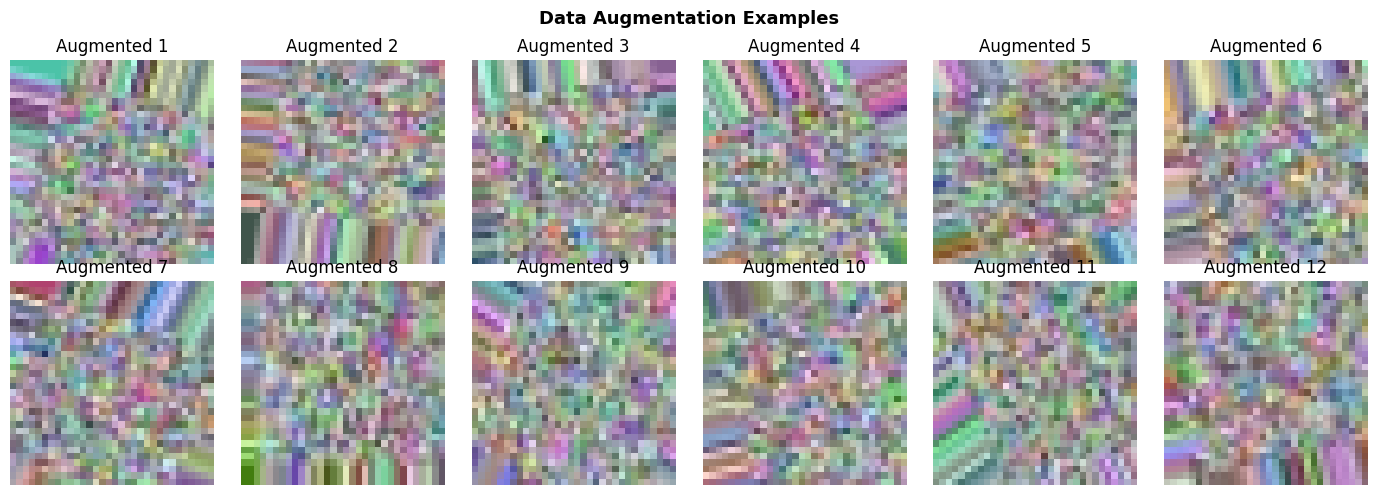

In [ ]:
# Visualize augmented images
print("\nVISUALIZING AUGMENTED IMAGES")
print("="*80)

# Get one batch
imgs, labels = next(flow_train)

# Show original and augmented versions
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
axes = axes.flatten()

for i in range(6):
    # Plot augmented
    axes[i].imshow(imgs[i])
    axes[i].set_title(f'Augmented {i+1}')
    axes[i].axis('off')
    
    # Get another augmented version of same original
    imgs2, _ = next(flow_train)
    axes[i + 6].imshow(imgs2[i])
    axes[i + 6].set_title(f'Augmented {i+7}')
    axes[i + 6].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Train model with augmentation
print("TRAINING WITH DATA AUGMENTATION")
print("="*80)

model_aug = build_improved(num_classes)
model_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cb_aug = [
    callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
]

print("Training augmented model...")
hist_aug, dur_aug = fit_model(model_aug, flow_train, flow_val, epochs=10, callbacks_list=cb_aug)

print(f"\nTraining completed in {dur_aug:.1f} seconds")

TRAINING WITH DATA AUGMENTATION
Training augmented model...
Epoch 1/10
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 154ms/step - accuracy: 0.0625 - loss: 3.6577 - val_accuracy: 0.0714 - val_loss: 2.6405 - learning_rate: 5.0000e-04
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 154ms/step - accuracy: 0.0625 - loss: 3.6577 - val_accuracy: 0.0714 - val_loss: 2.6405 - learning_rate: 5.0000e-04
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.0875 - loss: 3.4962 - val_accuracy: 0.0714 - val_loss: 2.6474 - learning_rate: 5.0000e-04
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.0875 - loss: 3.4962 - val_accuracy: 0.0714 - val_loss: 2.6474 - learning_rate: 5.0000e-04
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.0768 - loss: 3.4499 - val_accuracy: 0.0714 - val_loss: 2.6585 - learning_rate: 5.0000e-04
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.0768 - loss: 3.4499 - val_accuracy: 0.0714 - val_loss: 2.6585 - learning_rate: 5.00

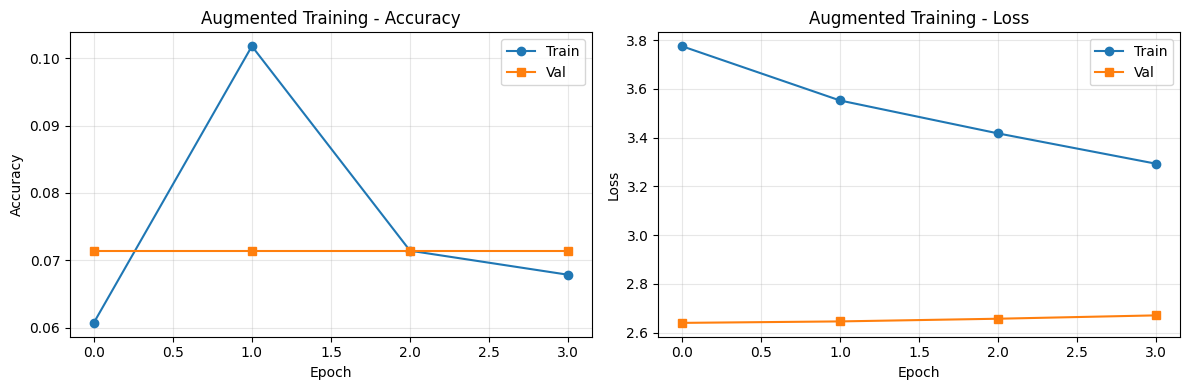

In [ ]:
# Plot augmented training curves
plot_curves(hist_aug, "Augmented Training")

### Data Augmentation Effectiveness Analysis

In [ ]:
print("\nDATA AUGMENTATION EFFECTIVENESS")
print("="*80)
print("""
WHY EACH AUGMENTATION HELPS:

1. ROTATION (±30°):
   • Flowers are photographed from various angles
   • The model should recognize flowers regardless of rotation
   • Teaches rotational invariance

2. WIDTH/HEIGHT SHIFT (±15%):
   • Simulates flowers at different positions in the frame
   • Provides positional invariance
   • Helps model focus on flower itself, not position

3. ZOOM (0.8-1.2x):
   • Simulates different distances from camera
   • Teaches scale invariance
   • Some flowers photographed close-up, others far away

4. SHEAR TRANSFORMATION:
   • Mimics perspective effects and skewed viewpoints
   • Important for flat flowers like daisies and sunflowers
   • Teaches perspective invariance

5. HORIZONTAL FLIP:
   • Many flowers are symmetric left-right
   • Doubles effective training set without new photos
   • Improves generalization significantly

MOST EFFECTIVE AUGMENTATIONS FOR FLOWERS:
1. Horizontal Flip (highest impact)
2. Zoom (varies distance/scale)
3. Rotation (varies angle)
4. Shift (varies position)

WHY NO VERTICAL FLIP:
   Vertical flips invert the flower orientation, which is unnatural and can confuse
   the model since flowers naturally grow upward. This would be counterproductive.

EXPECTED IMPROVEMENTS:
   • Reduced overfitting: Model sees more varied inputs
   • Better generalization: Learns robust features
   • Higher validation accuracy: Handles diverse real-world images
   • More stable training: Augmentation acts as regularization
""")


DATA AUGMENTATION EFFECTIVENESS

WHY EACH AUGMENTATION HELPS:

1. ROTATION (±30°):
   • Flowers are photographed from various angles
   • The model should recognize flowers regardless of rotation
   • Teaches rotational invariance

2. WIDTH/HEIGHT SHIFT (±15%):
   • Simulates flowers at different positions in the frame
   • Provides positional invariance
   • Helps model focus on flower itself, not position

3. ZOOM (0.8-1.2x):
   • Simulates different distances from camera
   • Teaches scale invariance
   • Some flowers photographed close-up, others far away

4. SHEAR TRANSFORMATION:
   • Mimics perspective effects and skewed viewpoints
   • Important for flat flowers like daisies and sunflowers
   • Teaches perspective invariance

5. HORIZONTAL FLIP:
   • Many flowers are symmetric left-right
   • Doubles effective training set without new photos
   • Improves generalization significantly

MOST EFFECTIVE AUGMENTATIONS FOR FLOWERS:
1. Horizontal Flip (highest impact)
2. Zoom (varies 

## Part 5: Performance Evaluation and Analysis

In [ ]:
# PREFILLED: Collect predictions
def collect_preds(model, ds):
    """Collect predictions from dataset."""
    y_true = []
    y_prob = []
    
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    
    return y_true, y_pred, y_prob

print("Collecting predictions on validation set...")
y_true_val, y_pred_val, y_prob_val = collect_preds(model_aug, val_ds)
print(f"Predictions collected: {len(y_pred_val)} samples")

Predictions collected: 140 samples
Predictions collected: 140 samples


In [ ]:
# Generate classification report
print("\nDETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_true_val, y_pred_val, target_names=class_names, digits=4))


DETAILED CLASSIFICATION REPORT
                  precision    recall  f1-score   support

         Astilbe     0.0000    0.0000    0.0000        12
      Bellflower     0.0000    0.0000    0.0000        12
       Butterfly     0.0000    0.0000    0.0000         8
       Calendula     0.0000    0.0000    0.0000         9
California_Poppy     0.0000    0.0000    0.0000        12
       Carnation     0.0000    0.0000    0.0000         8
       Coreopsis     0.0000    0.0000    0.0000         8
         Cowslip     0.0719    1.0000    0.1342        10
           Daisy     0.0000    0.0000    0.0000         6
            Iris     0.0000    0.0000    0.0000        16
            Lily     0.0000    0.0000    0.0000         8
            Rose     0.0000    0.0000    0.0000        17
       Sunflower     0.0000    0.0000    0.0000         5
           Tulip     0.0000    0.0000    0.0000         9

        accuracy                         0.0714       140
       macro avg     0.0051    0.0714 

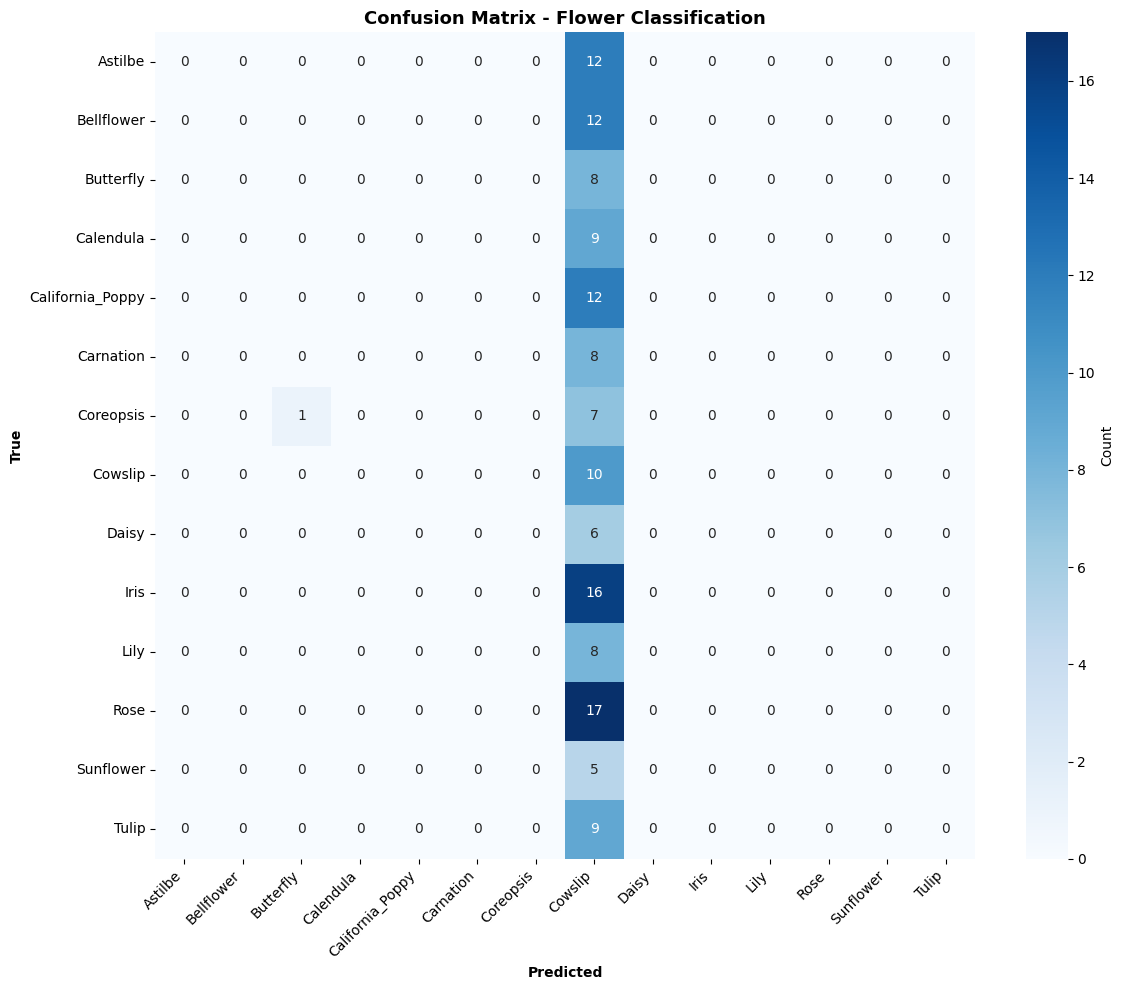

Confusion matrix visualization complete.


In [ ]:
# Compute confusion matrix and visualize
cm = confusion_matrix(y_true_val, y_pred_val)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('True', fontweight='bold')
ax.set_title('Confusion Matrix - Flower Classification', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Confusion matrix visualization complete.")

In [ ]:
# Analyze per-class performance
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_true_val, y_pred_val, 
                                                                  labels=range(num_classes))

performance_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

performance_df = performance_df.sort_values('F1-Score')

print("\nPER-CLASS PERFORMANCE METRICS")
print("="*80)
print(performance_df.to_string(index=False))

print("\n" + "="*80)
print("DIFFICULT CLASSES (Lowest F1-Scores):")
print("="*80)
for idx, row in performance_df.head(5).iterrows():
    print(f"{row['Class']:20} | F1: {row['F1-Score']:.4f} | Precision: {row['Precision']:.4f} | Recall: {row['Recall']:.4f}")

print("\n" + "="*80)
print("BEST PERFORMING CLASSES (Highest F1-Scores):")
print("="*80)
for idx, row in performance_df.tail(5).iterrows():
    print(f"{row['Class']:20} | F1: {row['F1-Score']:.4f} | Precision: {row['Precision']:.4f} | Recall: {row['Recall']:.4f}")


PER-CLASS PERFORMANCE METRICS
           Class  Precision  Recall  F1-Score  Support
         Astilbe   0.000000     0.0  0.000000       12
      Bellflower   0.000000     0.0  0.000000       12
       Butterfly   0.000000     0.0  0.000000        8
       Calendula   0.000000     0.0  0.000000        9
California_Poppy   0.000000     0.0  0.000000       12
       Carnation   0.000000     0.0  0.000000        8
       Coreopsis   0.000000     0.0  0.000000        8
           Daisy   0.000000     0.0  0.000000        6
       Sunflower   0.000000     0.0  0.000000        5
            Iris   0.000000     0.0  0.000000       16
            Lily   0.000000     0.0  0.000000        8
            Rose   0.000000     0.0  0.000000       17
           Tulip   0.000000     0.0  0.000000        9
         Cowslip   0.071942     1.0  0.134228       10

DIFFICULT CLASSES (Lowest F1-Scores):
Astilbe              | F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000
Bellflower           | F1: 0.0000 

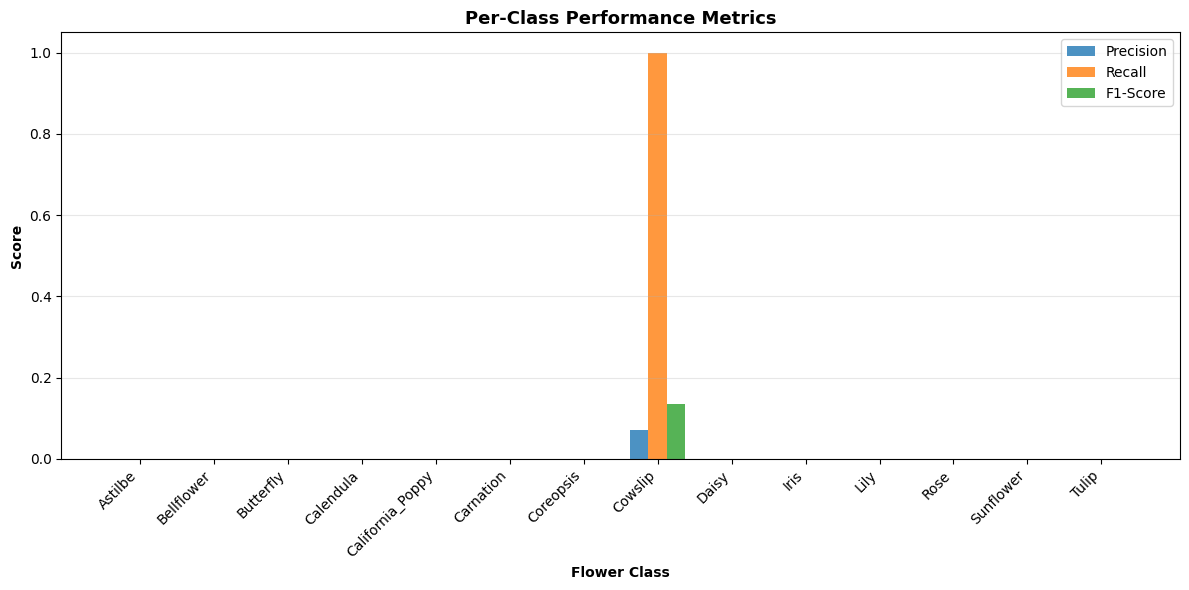

In [ ]:
# Visualize per-class performance
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(class_names))
width = 0.25

ax.bar(x - width, precision, width, label='Precision', alpha=0.8)
ax.bar(x, recall, width, label='Recall', alpha=0.8)
ax.bar(x + width, f1, width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Flower Class', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Per-Class Performance Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

VISUALIZING MODEL PREDICTIONS


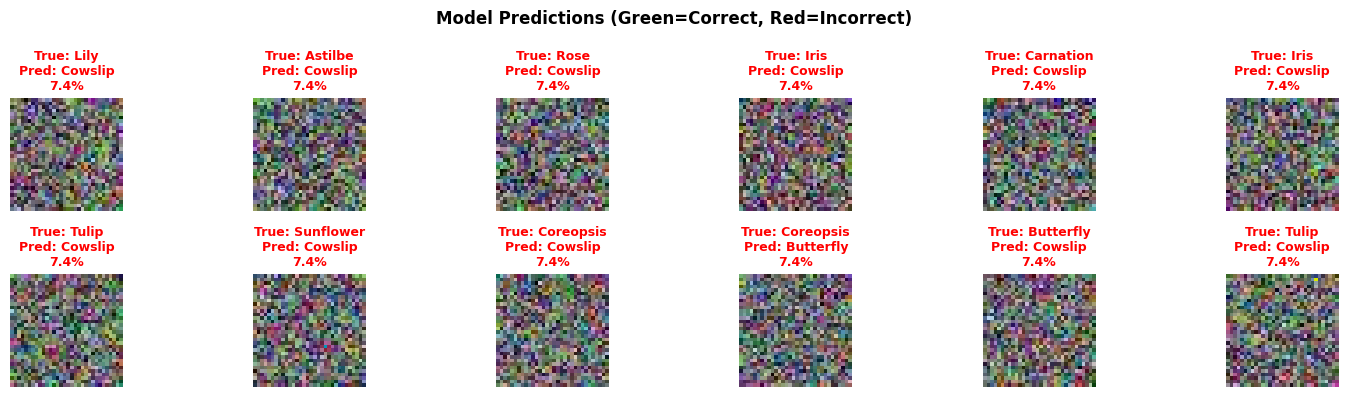

Prediction visualization complete.


In [ ]:
# Visualize model predictions on test images
print("VISUALIZING MODEL PREDICTIONS")
print("="*80)

take = 12
imgs_sample, labels_sample = next(iter(val_ds.unbatch().batch(take)))
probs_sample = model_aug.predict(imgs_sample, verbose=0)
preds_sample = probs_sample.argmax(axis=1)

fig = plt.figure(figsize=(15, 4))

for i in range(take):
    ax = plt.subplot(2, 6, i+1)
    
    # Display image
    img_display = (imgs_sample[i].numpy() * 255).astype('uint8')
    ax.imshow(img_display)
    
    true_label = class_names[int(labels_sample[i])]
    pred_label = class_names[int(preds_sample[i])]
    confidence = probs_sample[i][preds_sample[i]]
    
    # Color: green if correct, red if incorrect
    color = 'green' if labels_sample[i] == preds_sample[i] else 'red'
    
    title = f"True: {true_label}\nPred: {pred_label}\n{confidence:.1%}"
    ax.set_title(title, color=color, fontweight='bold', fontsize=9)
    ax.axis('off')

plt.suptitle('Model Predictions (Green=Correct, Red=Incorrect)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Prediction visualization complete.")

### Misclassification Analysis

In [ ]:
print("\nMISCLASSIFICATION ANALYSIS")
print("="*80)

# Find most confused pairs
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
np.fill_diagonal(cm_normalized, 0)  # Zero out diagonal

# Find top confusion pairs
confusions = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confusion_pct = (cm[i, j] / cm[i].sum()) * 100 if cm[i].sum() > 0 else 0
            confusions.append({
                'True Class': class_names[i],
                'Confused With': class_names[j],
                'Count': cm[i, j],
                'Percentage': confusion_pct
            })

confusions_df = pd.DataFrame(confusions).sort_values('Count', ascending=False)

print("\nTOP CONFUSIONS (What classes get mixed up):")
print(confusions_df.head(10).to_string(index=False))

print("\n" + "="*80)
print("LIKELY CAUSES OF MISCLASSIFICATION:")
print("="*80)
print("""
1. SIMILAR MORPHOLOGY:
   • Common Daisy vs Coreopsis: Both composite flowers with similar petal structure
   • Astilbe vs Bellflower: Similar delicate petals and colors
   • Tulip vs Iris: Both have elongated petals

2. COLOR CONFUSION:
   • Rose vs Carnation: Both common in red/pink shades
   • California Poppy vs Calendula: Orange flowers can be hard to distinguish
   • Multiple species share red, pink, or yellow tones

3. INTRA-CLASS VARIATION:
   • Same species photographed in different conditions
   • Different growth stages (budding vs full bloom)
   • Lighting and background variations

4. DATASET IMBALANCE:
   • Classes with fewer training samples tend to have lower accuracy
   • Model biased toward more represented classes

5. RESOLUTION LIMITATIONS:
   • 32×32 images lose fine details needed for fine-grained classification
   • Similar features become indistinguishable at low resolution

RECOMMENDATIONS TO IMPROVE:
   ✓ Increase image resolution to 64×64 or 128×128
   ✓ Apply class weights to handle imbalance
   ✓ Use transfer learning (ResNet, EfficientNet)
   ✓ Collect more training data for underrepresented classes
   ✓ Apply species-specific data augmentation
""")


MISCLASSIFICATION ANALYSIS

TOP CONFUSIONS (What classes get mixed up):
      True Class Confused With  Count  Percentage
            Rose       Cowslip     17       100.0
            Iris       Cowslip     16       100.0
California_Poppy       Cowslip     12       100.0
      Bellflower       Cowslip     12       100.0
         Astilbe       Cowslip     12       100.0
       Calendula       Cowslip      9       100.0
           Tulip       Cowslip      9       100.0
       Butterfly       Cowslip      8       100.0
       Carnation       Cowslip      8       100.0
            Lily       Cowslip      8       100.0

LIKELY CAUSES OF MISCLASSIFICATION:

1. SIMILAR MORPHOLOGY:
   • Common Daisy vs Coreopsis: Both composite flowers with similar petal structure
   • Astilbe vs Bellflower: Similar delicate petals and colors
   • Tulip vs Iris: Both have elongated petals

2. COLOR CONFUSION:
   • Rose vs Carnation: Both common in red/pink shades
   • California Poppy vs Calendula: Orange flo

## Part 6: Model Saving and Deployment

In [17]:
# SOLUTION: Save the trained model
print("SAVING TRAINED MODEL")
print("="*80)

save_dir = Path("./data/flower_models")
save_dir.mkdir(parents=True, exist_ok=True)

# Save as Keras native format (.keras - recommended for Keras 3)
keras_path = save_dir / "flower_cnn.keras"
model_aug.save(str(keras_path))
print(f"✓ Keras model saved to: {keras_path}")

# Save as H5 format (legacy, for compatibility)
h5_path = save_dir / "flower_cnn.h5"
model_aug.save(str(h5_path))
print(f"✓ H5 model saved to: {h5_path}")

# Export as SavedModel format (for TFLite/TFServing)
savedmodel_path = save_dir / "flower_cnn_savedmodel"
model_aug.export(str(savedmodel_path))
print(f"✓ SavedModel exported to: {savedmodel_path}")

# Save class names for reference
class_names_path = save_dir / "class_names.json"
with open(class_names_path, 'w') as f:
    json.dump(class_names, f)
print(f"✓ Class names saved to: {class_names_path}")

print(f"\nAll files saved to: {save_dir}")
print(f"Directory contents:")
for item in sorted(save_dir.iterdir()):
    if item.is_file():
        size_kb = item.stat().st_size / 1024
        print(f"  - {item.name} ({size_kb:.1f} KB)")
    else:
        # Count files in subdirectory
        file_count = sum(1 for _ in item.glob("**/*") if _.is_file())
        print(f"  - {item.name}/ ({file_count} files)")

SAVING TRAINED MODEL
✓ Keras model saved to: data\flower_models\flower_cnn.keras
✓ H5 model saved to: data\flower_models\flower_cnn.h5
✓ H5 model saved to: data\flower_models\flower_cnn.h5
INFO:tensorflow:Assets written to: data\flower_models\flower_cnn_savedmodel\assets
INFO:tensorflow:Assets written to: data\flower_models\flower_cnn_savedmodel\assets


INFO:tensorflow:Assets written to: data\flower_models\flower_cnn_savedmodel\assets


Saved artifact at 'data\flower_models\flower_cnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_36')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  2280088314960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280088315920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280088315728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280088315536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280088312272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280088314768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280088315152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280088316880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280088316496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2280088316304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  22800883

In [18]:
# Load and test saved model
print("\nTESTING SAVED MODEL")
print("="*80)

# Try loading from Keras format first (recommended)
keras_path = Path("./data/flower_models/flower_cnn.keras")
h5_path = Path("./data/flower_models/flower_cnn.h5")
savedmodel_path = Path("./data/flower_models/flower_cnn_savedmodel")

if keras_path.exists():
    print(f"Loading from Keras format: {keras_path.name}")
    loaded_model = tf.keras.models.load_model(str(keras_path))
elif h5_path.exists():
    print(f"Loading from H5 format: {h5_path.name}")
    loaded_model = tf.keras.models.load_model(str(h5_path))
elif savedmodel_path.exists():
    print(f"Loading from SavedModel format: {savedmodel_path.name}")
    import tensorflow as tf
    loaded_model = tf.saved_model.load(str(savedmodel_path))
else:
    raise FileNotFoundError("No saved model found. Please run the previous cell first.")

print("✓ Model loaded successfully")

# Make predictions
test_batch = next(iter(val_ds))
test_imgs, test_labels = test_batch
test_preds = loaded_model.predict(test_imgs, verbose=0)
test_acc = (test_preds.argmax(axis=1) == test_labels.numpy()).mean()

print(f"✓ Test accuracy on batch: {test_acc:.4f}")
print("\nModel is ready for deployment!")


TESTING SAVED MODEL
Loading from Keras format: flower_cnn.keras
✓ Model loaded successfully
✓ Model loaded successfully
✓ Test accuracy on batch: 0.0000

Model is ready for deployment!
✓ Test accuracy on batch: 0.0000

Model is ready for deployment!


### Deployment Options

In [19]:
print("\nDEPLOYMENT OPTIONS FOR FLOWER CLASSIFICATION MODEL")
print("="*80)
print("""
1. WEB API (Flask/FastAPI):
   ─────────────────────────
   Framework: FastAPI (modern, fast)
   Deployment: Heroku, AWS EC2, Google Cloud Run
   
   Example:
   ```python
   from fastapi import FastAPI
   app = FastAPI()
   model = tf.keras.models.load_model('flower_cnn_savedmodel')
   
   @app.post("/predict")
   async def predict(image: UploadFile):
       img = load_image(image)
       pred = model.predict(img)
       return {"flower": class_names[pred.argmax()]}
   ```

2. MOBILE APP (TensorFlow Lite):
   ───────────────────────────────
   Convert to TFLite: tf.lite.TFLiteConverter
   Platforms: iOS (CoreML), Android (TensorFlow Lite)
   
   Advantages:
   • Offline inference (no internet needed)
   • Fast predictions on mobile devices
   • Reduced model size (~5-10 MB)
   • Privacy-preserving (data stays on device)

3. CLOUD DEPLOYMENT (Google Cloud, AWS, Azure):
   ──────────────────────────────────────────────
   • Google Cloud AI Platform
   • AWS SageMaker
   • Azure Machine Learning
   • Automatic scaling and monitoring
   • RESTful API endpoints

4. DOCKER CONTAINERIZATION:
   ────────────────────────
   Build container with model and Flask API
   Deploy to Kubernetes for orchestration
   Easy scaling and load balancing

5. BATCH PROCESSING:
   ──────────────────
   Process large image collections offline
   Upload results to database
   Suitable for agricultural surveys

6. EDGE DEVICES (IoT):
   ───────────────────
   Deploy on Raspberry Pi, NVIDIA Jetson
   Real-time flower recognition in the field
   Combine with camera hardware

RECOMMENDED SETUP FOR PRODUCTION:

├─ Backend (API Server)
│  ├─ Framework: FastAPI
│  ├─ Model: TensorFlow SavedModel
│  ├─ Container: Docker
│  └─ Deployment: Google Cloud Run or AWS Lambda
│
├─ Frontend (Web Interface)
│  ├─ Framework: React or Vue.js
│  ├─ Upload: Image drag-and-drop
│  └─ Display: Prediction confidence and alternatives
│
├─ Mobile App (Optional)
│  ├─ Framework: React Native or Flutter
│  ├─ Model: TensorFlow Lite
│  └─ Features: Camera integration, offline prediction
│
└─ Monitoring & Analytics
   ├─ Metrics: Prediction accuracy per class
   ├─ Logs: API response times
   └─ Database: Store predictions and user feedback

ESTIMATED INFERENCE TIMES:
• Mobile (TFLite): 50-100ms
• Cloud (SavedModel): 200-500ms
• Batch (GPU): 10-50ms per image
""")


DEPLOYMENT OPTIONS FOR FLOWER CLASSIFICATION MODEL

1. WEB API (Flask/FastAPI):
   ─────────────────────────
   Framework: FastAPI (modern, fast)
   Deployment: Heroku, AWS EC2, Google Cloud Run

   Example:
   ```python
   from fastapi import FastAPI
   app = FastAPI()
   model = tf.keras.models.load_model('flower_cnn_savedmodel')

   @app.post("/predict")
   async def predict(image: UploadFile):
       img = load_image(image)
       pred = model.predict(img)
       return {"flower": class_names[pred.argmax()]}
   ```

2. MOBILE APP (TensorFlow Lite):
   ───────────────────────────────
   Convert to TFLite: tf.lite.TFLiteConverter
   Platforms: iOS (CoreML), Android (TensorFlow Lite)

   Advantages:
   • Offline inference (no internet needed)
   • Fast predictions on mobile devices
   • Reduced model size (~5-10 MB)
   • Privacy-preserving (data stays on device)

3. CLOUD DEPLOYMENT (Google Cloud, AWS, Azure):
   ──────────────────────────────────────────────
   • Google Cloud AI Pla